# 08 - Spatially Variable Genes (Moran's I)

## Learning objectives
1. Build the spatial neighbor graph and compute spatial autocorrelation (Moran's I).
2. Identify genes with spatial structure (SVGs) and visualize them.
3. Explain how SVGs differ from highly variable genes (HVGs).

## Concept
**HVGs** are genes with high variance across spots - but variance ignores *position*. A
gene could be high-variance yet scattered randomly. **SVGs** are genes whose expression is
**spatially organized**: nearby spots have similar values. **Moran's I** measures exactly
that (~ -1..+1; high positive = strong spatial pattern). Think of it as detecting genes
that form coherent 'regions' rather than salt-and-pepper noise.


In [1]:
# --- Standard setup: make `utils` importable and seed RNGs ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'utils').exists():
    ROOT = ROOT.parent  # in case the notebook is opened from a subfolder
sys.path.insert(0, str(ROOT))

from utils import st_helpers as st
st.set_seeds()  # reproducibility (seed = 0)
print('Project root:', st.project_root())


Project root: /Users/justin/Documents/SpatialTranscriptomics-Tutorial


In [2]:
import scanpy as sc
import squidpy as sq

adata = st.load_adata('adata_clustered.h5ad')
# Ensure the spatial graph exists (created in nb 07, but be self-contained).
if 'spatial_connectivities' not in adata.obsp:
    sq.gr.spatial_neighbors(adata, coord_type='grid', n_neighs=6)
adata


AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'clusters', 'clusters_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', '

### Compute Moran's I
We test the highly variable genes (computing on all ~18k genes is slow and mostly noise).
Results land in `adata.uns['moranI']`, sorted by the statistic.

In [3]:
hvg = adata.var_names[adata.var['highly_variable']].tolist() if 'highly_variable' in adata.var else adata.var_names[:2000].tolist()
print('Testing', len(hvg), 'genes for spatial autocorrelation...')
sq.gr.spatial_autocorr(adata, mode='moran', genes=hvg, n_perms=100,
                       n_jobs=1, seed=st.SEED)
moran = adata.uns['moranI']
moran.head(15)


Testing 2000 genes for spatial autocorrelation...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
Mbp,0.788332,0.0,0.000131,0.0,0.009901,0.000273,0.0,0.0,0.013647
Slc17a7,0.775264,0.0,0.000131,0.0,0.009901,0.000240,0.0,0.0,0.013647
Nrgn,0.743275,0.0,0.000131,0.0,0.009901,0.000306,0.0,0.0,0.013647
Cck,0.727492,0.0,0.000131,0.0,0.009901,0.000246,0.0,0.0,0.013647
Itpka,0.697989,0.0,0.000131,0.0,0.009901,0.000241,0.0,0.0,0.013647
Mobp,0.696181,0.0,0.000131,0.0,0.009901,0.000241,0.0,0.0,0.013647
Camk2n1,0.694698,0.0,0.000131,0.0,0.009901,0.000236,0.0,0.0,0.013647
Plp1,0.689478,0.0,0.000131,0.0,0.009901,0.000226,0.0,0.0,0.013647
Baiap3,0.689079,0.0,0.000131,0.0,0.009901,0.000288,0.0,0.0,0.013647
Ddn,0.681464,0.0,0.000131,0.0,0.009901,0.000156,0.0,0.0,0.013647


**Expected output:** a table indexed by gene with an `I` column (and a p-value), sorted
descending. Top genes have `I` well above 0 - strong spatial structure.

### Visualize the top SVGs over tissue

Top SVGs: ['Mbp', 'Slc17a7', 'Nrgn', 'Cck', 'Itpka', 'Mobp']


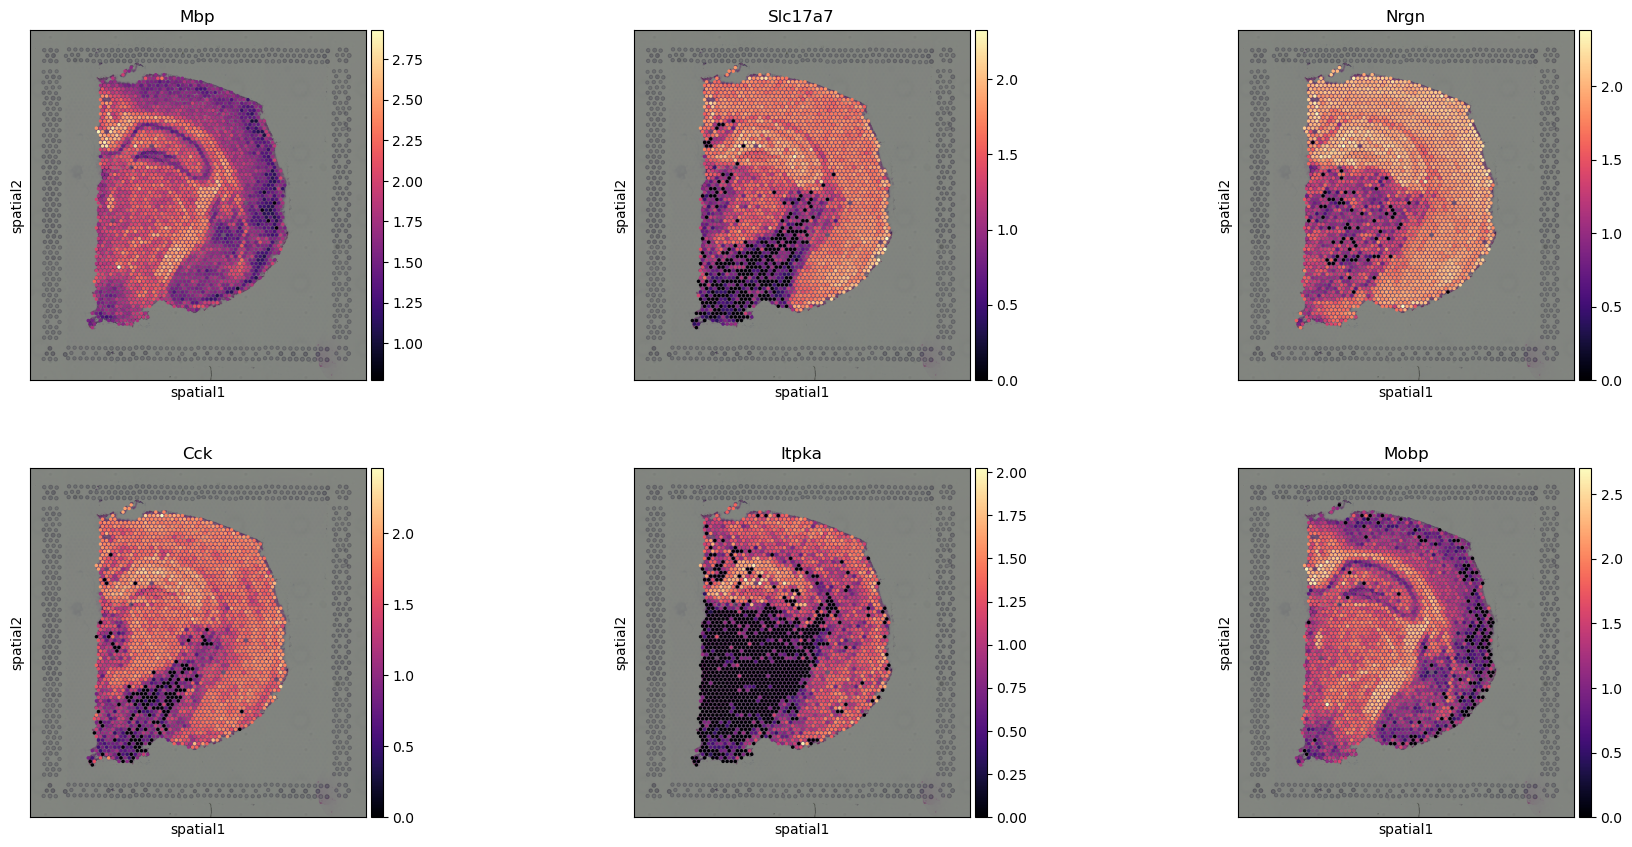

In [4]:
top_svgs = st.genes_present(adata, moran.head(6).index.tolist())
print('Top SVGs:', top_svgs)
sq.pl.spatial_scatter(adata, color=top_svgs, ncols=3, size=1.3, cmap='magma')


### SVGs vs HVGs - how much do they overlap?
A gene can be highly variable but not spatially structured, and vice versa. Let's compare.

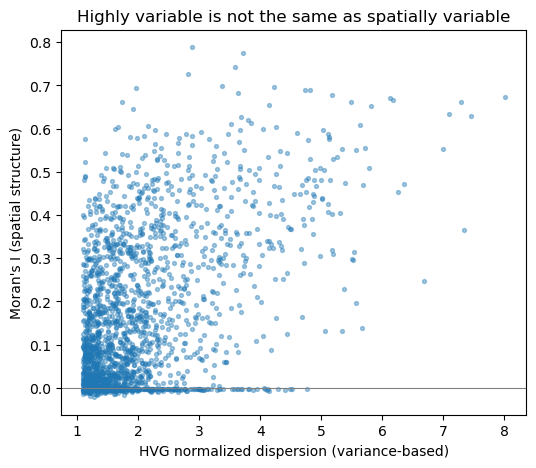

Correlation between dispersion and Moran I: 0.477


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Rank genes by HVG dispersion and by Moran's I, then look at the relationship.
common = [g for g in moran.index if g in adata.var_names]
I_vals = moran.loc[common, 'I']
disp = adata.var.loc[common, 'dispersions_norm'] if 'dispersions_norm' in adata.var else None

if disp is not None:
    plt.figure(figsize=(6, 5))
    plt.scatter(disp, I_vals, s=8, alpha=0.4)
    plt.xlabel('HVG normalized dispersion (variance-based)')
    plt.ylabel("Moran's I (spatial structure)")
    plt.title('Highly variable is not the same as spatially variable')
    plt.axhline(0, color='gray', lw=0.8)
    plt.show()
    print('Correlation between dispersion and Moran I:',
          round(float(np.corrcoef(disp, I_vals)[0, 1]), 3))


### Moran's I rank plot (top spatially structured genes)

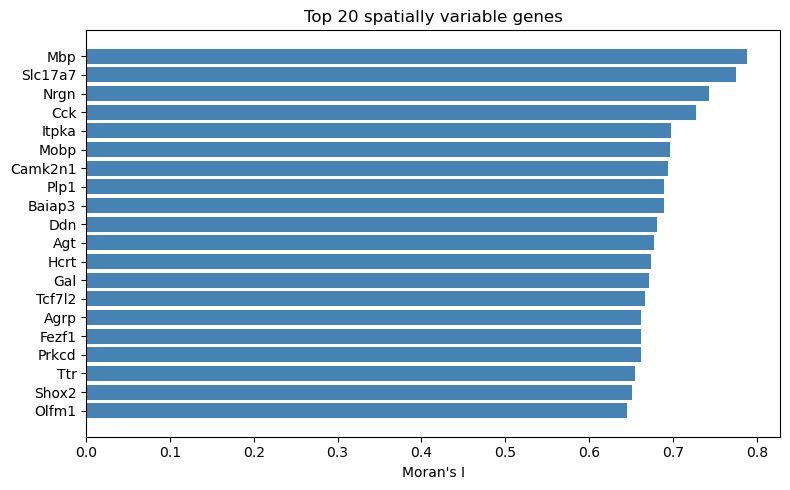

In [6]:
import matplotlib.pyplot as plt

top20 = moran.head(20)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top20.index[::-1], top20['I'].values[::-1], color='steelblue')
ax.set_xlabel("Moran's I")
ax.set_title('Top 20 spatially variable genes')
plt.tight_layout()
st.save_fig(fig, '08_moran_rank.png')
plt.show()


### Counterexample: high variance but weak spatial structure
Find a gene that is highly variable (HVG) but **not** in the top SVGs — its expression
varies across spots but without coherent spatial patches.

Counterexample gene: Myoc  (Moran I = 0.365)


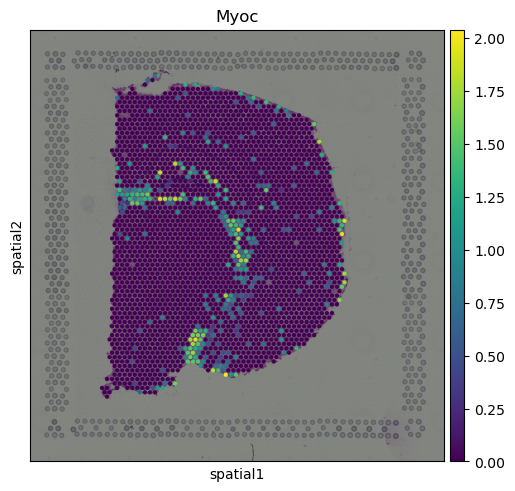

In [7]:
import numpy as np

hvg_set = set(adata.var_names[adata.var['highly_variable']]) if 'highly_variable' in adata.var else set()
top_svg_set = set(moran.head(50).index)
candidates = [g for g in adata.var_names if g in hvg_set and g not in top_svg_set]
counter = None
if candidates and 'dispersions_norm' in adata.var:
    disp = adata.var.loc[candidates, 'dispersions_norm']
    counter = disp.idxmax()
    I_val = moran.loc[counter, 'I'] if counter in moran.index else float('nan')
    print(f'Counterexample gene: {counter}  (Moran I = {I_val:.3f})')
    sq.pl.spatial_scatter(adata, color=counter, size=1.3, cmap='viridis')
    fig = plt.gcf()
    st.save_fig(fig, '08_hvg_not_svg_counterexample.png')
else:
    print('Could not find a counterexample; inspect moran and HVG tables manually.')


<details>
<summary><b>Your turn (exercise)</b></summary>

**Prompt:** Why might a gene be highly variable across spots but have low Moran's I?

**Expected answer:** Its expression changes a lot between spots but **without spatial
autocorrelation** — e.g. random salt-and-pepper noise, spot-level technical variation, or
a program active in scattered cell types rather than coherent tissue regions.
</details>


**Expected output:** a weak/moderate positive but clearly scattered relationship - many
high-dispersion genes have modest Moran's I, confirming the two notions are related but
**not** the same.

## Common pitfalls
- Forgetting `sq.gr.spatial_neighbors` first - Moran's I needs the spatial graph.
- Testing all genes - slow and dominated by noise; restrict to HVGs.
- Reading Moran's I as effect size - it measures *pattern*, not magnitude of expression.

## Interpretation
SVGs are the genes that 'draw the map' - those whose expression respects tissue geography.
They are the natural targets for spatial-domain interpretation.

## What this means biologically
Spatially structured genes typically mark anatomical compartments or gradients (e.g.
cortical-layer or region-specific programs). They are prime candidates for understanding
how function is organized across the tissue - and, in disease, how niches differ.

---
**Next:** `09_image_feature_extraction_from_histology.ipynb`.
